In [1]:
import sys
import os

# Adds the parent directory to sys.path
sys.path.append(os.path.abspath('..'))

In [2]:
from sklearn.datasets import make_blobs, make_moons, make_circles, make_classification, make_gaussian_quantiles
import importlib
import warnings

warnings.filterwarnings('ignore')

# Moons

In [3]:
 
# Dataset options
dataset_options = {
        'blobs': lambda: make_blobs(n_samples=500, centers=3, cluster_std=1.0, random_state=42),
        'moons': lambda: make_moons(n_samples=500, noise=0.05, random_state=42),
        'circles': lambda: make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42),
        'classification': lambda: make_classification(n_samples=500, n_features=2, n_informative=2, n_clusters_per_class=1, random_state=42),
        'gaussian_quantiles': lambda: make_gaussian_quantiles(n_samples=500, n_features=2, random_state=42)
    }

dataset_name = 'moons'  # Change this to use a different dataset
data, _ = dataset_options[dataset_name]()

In [4]:
from utils.hyper_param_opt import hyper_param_search

hyper_param_search(data, percentage_outliers=0.1, num_clusters=2, top_n=10)

Processing DBSCAN parameters: 100%|██████| 12600/12600 [01:07<00:00, 186.19it/s]


,num_clusters,percentage_outliers,eps,min_samples,metric,algorithm,leaf_size,p,silhouette_score
2041,2,0.016,0.2,7,manhattan,auto,10,1.0,0.282852
2068,2,0.016,0.2,7,manhattan,ball_tree,50,1.0,0.282852
2067,2,0.016,0.2,7,manhattan,ball_tree,50,NaN,0.282852
2066,2,0.016,0.2,7,manhattan,ball_tree,40,2.0,0.282852
2065,2,0.016,0.2,7,manhattan,ball_tree,40,1.0,0.282852
2064,2,0.016,0.2,7,manhattan,ball_tree,40,NaN,0.282852
2063,2,0.016,0.2,7,manhattan,ball_tree,30,2.0,0.282852
2062,2,0.016,0.2,7,manhattan,ball_tree,30,1.0,0.282852
2061,2,0.016,0.2,7,manhattan,ball_tree,30,NaN,0.282852
2060,2,0.016,0.2,7,manhattan,ball_tree,20,2.0,0.282852


In [5]:
from utils.outlier_detection_by_clust import create_dbscan_and_clean_data


cleaned_data = create_dbscan_and_clean_data(data, eps=0.2, min_samples=7,
                                                                   metric='manhattan', algorithm='auto',
                                                                      leaf_size=10, p=1, plot=False)

Percentage of outliers removed: 1.60%
Number of clusters found: 2


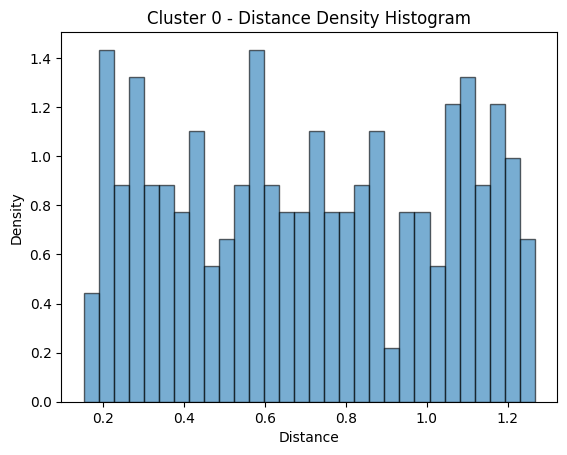

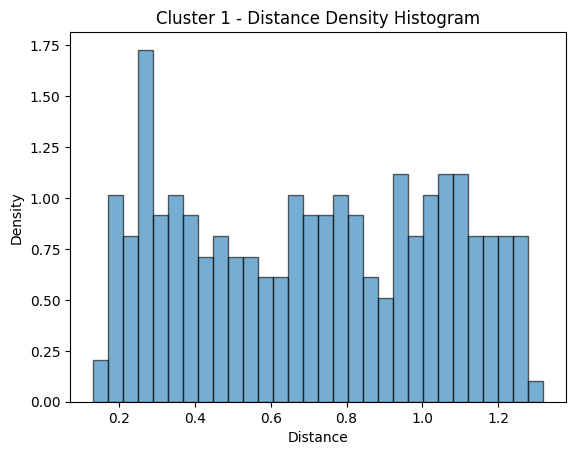

In [6]:
from utils.weighted_distance_calculation import plot_density_histograms

plot_density_histograms('../data/outlier_cleaned_by_DBSCAN.csv')

In [7]:
from utils.outlier_detection_by_dist import filter_and_save_by_cluster


threshold = {'0':1.1, '1':1.05}

filter_and_save_by_cluster('../data/weighted_distances.csv', threshold, plot=False)

Filtered dataframe has been saved to '../data/final_cleaned.csv'
Outliers have been saved to '../data/outliers.csv'


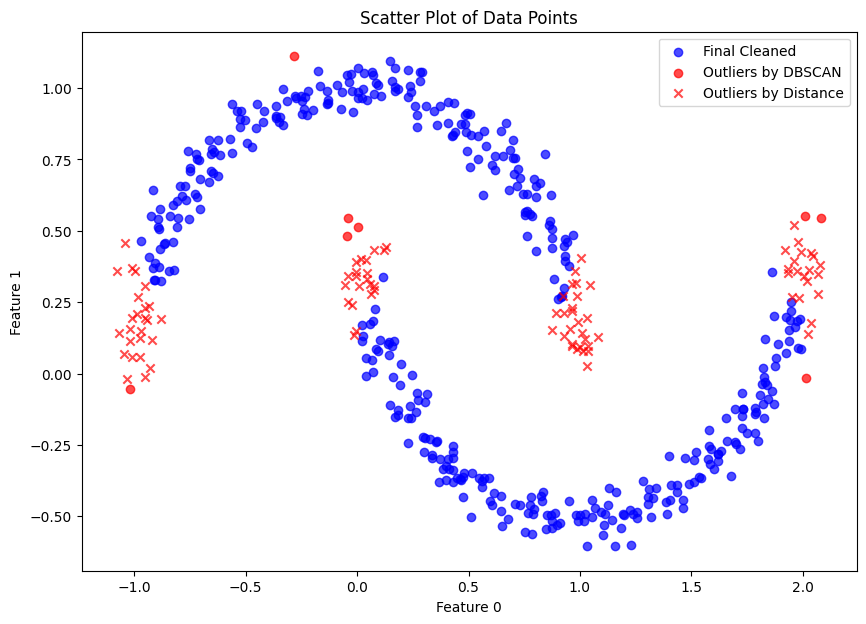

In [8]:
from utils.final_plot import plot_data_points

plot_data_points()

# Blobs

In [8]:
 
# Dataset options
dataset_options = {
        'blobs': lambda: make_blobs(n_samples=500, centers=3, cluster_std=1.0, random_state=42),
        'moons': lambda: make_moons(n_samples=500, noise=0.05, random_state=42),
        'circles': lambda: make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42),
        'classification': lambda: make_classification(n_samples=500, n_features=2, n_informative=2, n_clusters_per_class=1, random_state=42),
        'gaussian_quantiles': lambda: make_gaussian_quantiles(n_samples=500, n_features=2, random_state=42)
    }

dataset_name = 'blobs'  # Change this to use a different dataset
data, _ = dataset_options[dataset_name]()

In [9]:
from hyper_param_opt import hyper_param_search

hyper_param_search(data, percentage_outliers=0.1, num_clusters=3, top_n=10)

Processing DBSCAN parameters: 100%|███████████████████| 7560/7560 [01:03<00:00, 119.72it/s]


,num_clusters,percentage_outliers,eps,min_samples,metric,algorithm,leaf_size,p,silhouette_score
341,3,0.104,0.1,6,euclidean,ball_tree,50,2.0,0.678142
357,3,0.104,0.1,6,euclidean,brute,50,NaN,0.678142
356,3,0.104,0.1,6,euclidean,brute,30,2.0,0.678142
355,3,0.104,0.1,6,euclidean,brute,30,1.0,0.678142
354,3,0.104,0.1,6,euclidean,brute,30,NaN,0.678142
353,3,0.104,0.1,6,euclidean,brute,10,2.0,0.678142
352,3,0.104,0.1,6,euclidean,brute,10,1.0,0.678142
351,3,0.104,0.1,6,euclidean,brute,10,NaN,0.678142
350,3,0.104,0.1,6,euclidean,kd_tree,50,2.0,0.678142
349,3,0.104,0.1,6,euclidean,kd_tree,50,1.0,0.678142


In [10]:
import outlier_detection_by_clust
importlib.reload(outlier_detection_by_clust)


cleaned_data = outlier_detection_by_clust.create_dbscan_and_clean_data(data, eps=0.1, min_samples=6,
                                                                   metric='euclidean', algorithm='ball_tree',
                                                                      leaf_size=50, p=2, plot=False)

Percentage of outliers removed: 10.40%
Number of clusters found: 3


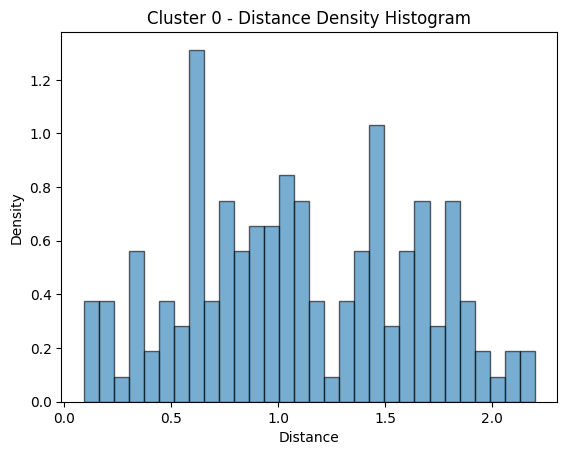

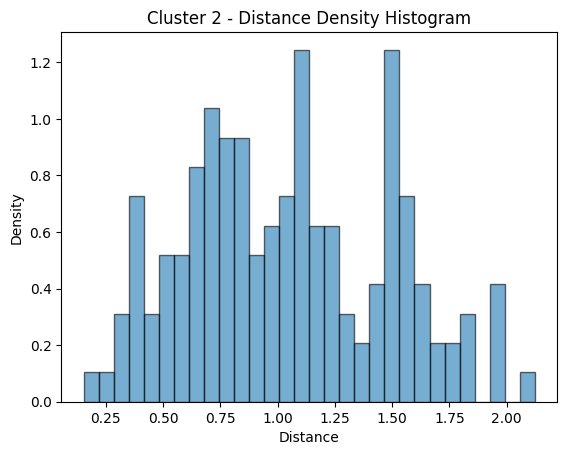

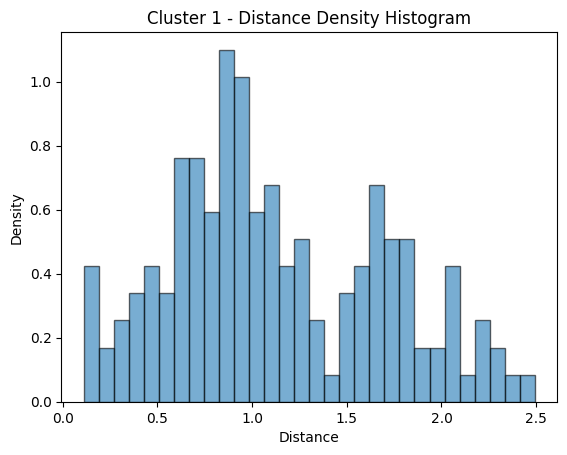

In [11]:
import weighted_distance_calculation
importlib.reload(weighted_distance_calculation)

weighted_distance_calculation.plot_density_histograms('data/outlier_cleaned_by_DBSCAN.csv')

In [12]:
import outlier_detection_by_dist
importlib.reload(outlier_detection_by_dist)


threshold = {'0':2, '1':2.1 ,'2':1.75}

outlier_detection_by_dist.filter_and_save_by_cluster('./data/weighted_distances.csv', threshold, plot=False)

Filtered dataframe has been saved to './data/final_cleaned.csv'
Outliers have been saved to './data/outliers.csv'


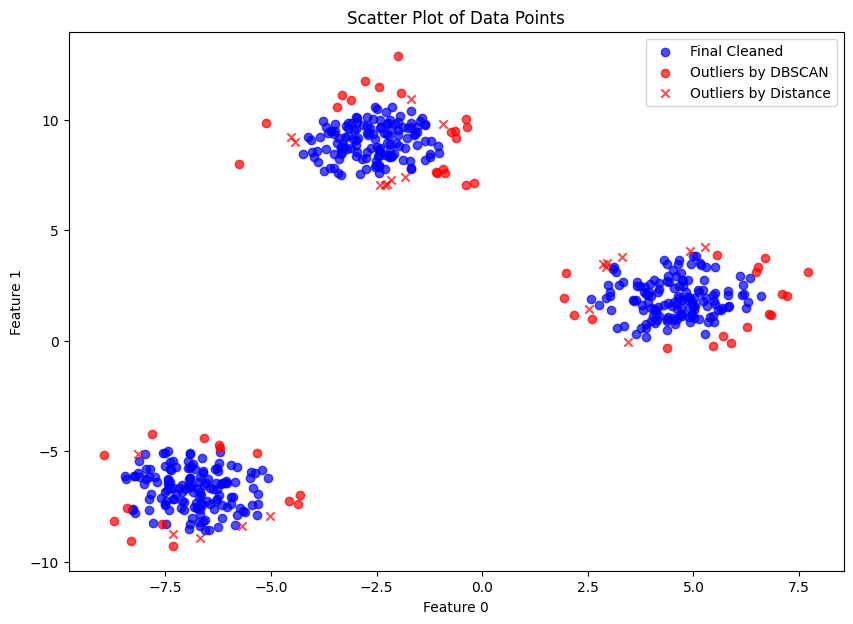

In [13]:
import final_plot
importlib.reload(final_plot)

final_plot.plot_data_points()

# gaussian_quantiles

In [14]:
 
# Dataset options
dataset_options = {
        'blobs': lambda: make_blobs(n_samples=500, centers=3, cluster_std=1.0, random_state=42),
        'moons': lambda: make_moons(n_samples=500, noise=0.05, random_state=42),
        'circles': lambda: make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42),
        'gaussian_quantiles': lambda: make_gaussian_quantiles(n_samples=500, n_features=2, random_state=42)
    }

dataset_name = 'gaussian_quantiles'  # Change this to use a different dataset
data, _ = dataset_options[dataset_name]()

In [15]:
from hyper_param_opt import hyper_param_search

hyper_param_search(data, percentage_outliers=0.1, num_clusters=3, top_n=10)

Processing DBSCAN parameters: 100%|███████████████████| 7560/7560 [01:08<00:00, 109.59it/s]


,num_clusters,percentage_outliers,eps,min_samples,metric,algorithm,leaf_size,p,silhouette_score
2646,3,0.1,0.4,6,manhattan,kd_tree,10,NaN,0.024343
2662,3,0.1,0.4,6,manhattan,brute,50,1.0,0.024343
2661,3,0.1,0.4,6,manhattan,brute,50,NaN,0.024343
2660,3,0.1,0.4,6,manhattan,brute,30,2.0,0.024343
2659,3,0.1,0.4,6,manhattan,brute,30,1.0,0.024343
2658,3,0.1,0.4,6,manhattan,brute,30,NaN,0.024343
2657,3,0.1,0.4,6,manhattan,brute,10,2.0,0.024343
2656,3,0.1,0.4,6,manhattan,brute,10,1.0,0.024343
2655,3,0.1,0.4,6,manhattan,brute,10,NaN,0.024343
2654,3,0.1,0.4,6,manhattan,kd_tree,50,2.0,0.024343


In [16]:
import outlier_detection_by_clust
importlib.reload(outlier_detection_by_clust)


cleaned_data = outlier_detection_by_clust.create_dbscan_and_clean_data(data, eps=0.4, min_samples=6,
                                                                   metric='manhattan', algorithm='kd_tree',
                                                                      leaf_size=10, plot=False)

Percentage of outliers removed: 10.00%
Number of clusters found: 3


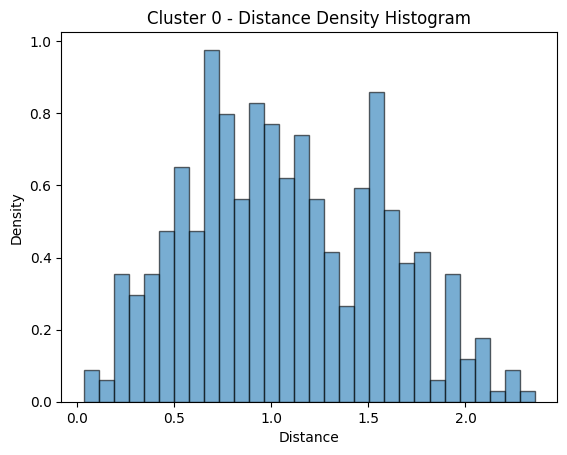

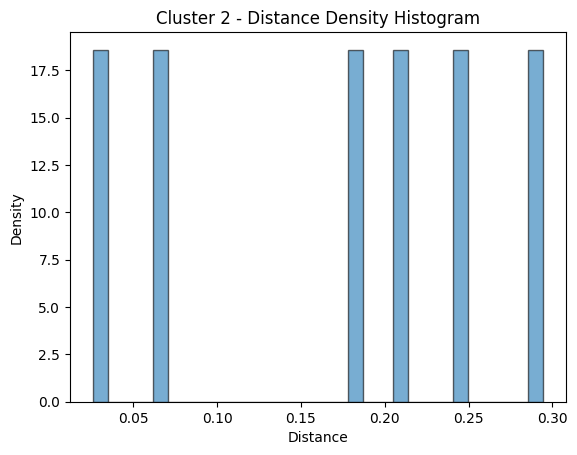

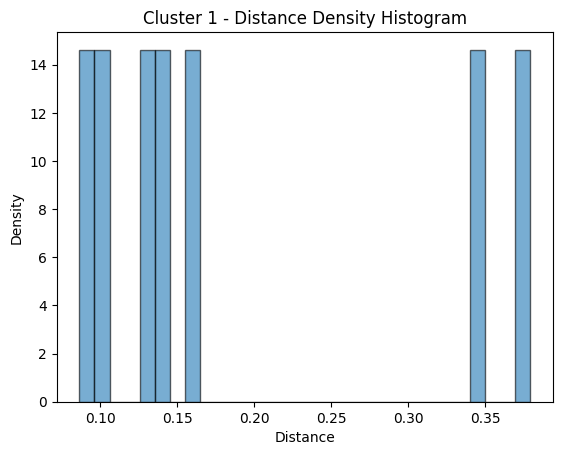

In [17]:
import weighted_distance_calculation
importlib.reload(weighted_distance_calculation)

weighted_distance_calculation.plot_density_histograms('data/outlier_cleaned_by_DBSCAN.csv')

In [18]:
import outlier_detection_by_dist
importlib.reload(outlier_detection_by_dist)


threshold = {'0':2, '1':0.2 ,'2':0.1}

outlier_detection_by_dist.filter_and_save_by_cluster('./data/weighted_distances.csv', threshold, plot=False)

Filtered dataframe has been saved to './data/final_cleaned.csv'
Outliers have been saved to './data/outliers.csv'


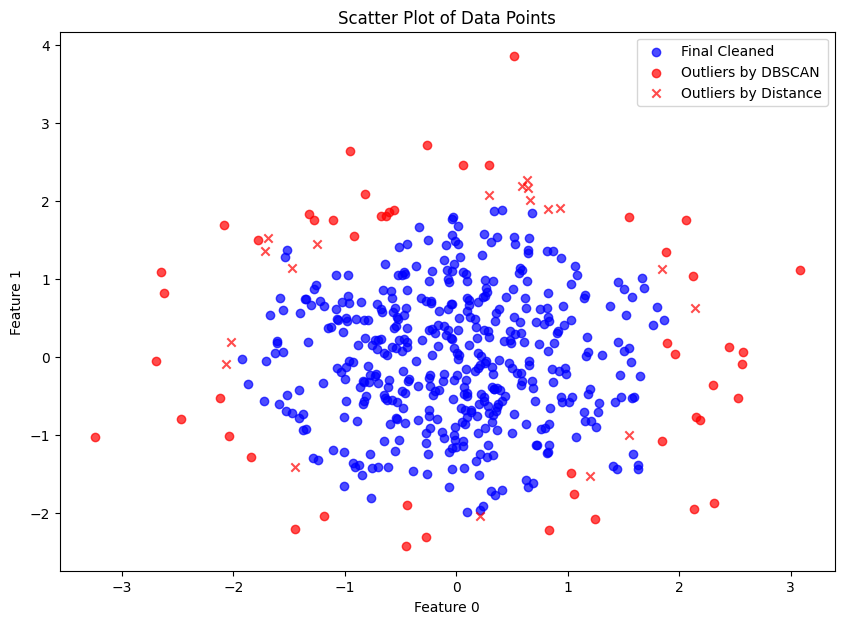

In [19]:
import final_plot
importlib.reload(final_plot)

final_plot.plot_data_points()

# Salary

In [2]:
import pandas as pd
data = pd.read_csv('../data/FAKE_People.csv')

In [3]:
data.sample(10)

,Gender,Age,City,Salary
551,Non-binary,65,Brescia,56565
535,Female,34,Padua,42058
71,Female,25,Bologna,40782
990,Non-binary,52,Milan,46166
524,Non-binary,55,Milan,47761
27,Non-binary,33,Brescia,33984
1088,Non-binary,48,Venice,87961
124,Female,49,Brescia,57301
88,Non-binary,56,Bologna,57349
527,Male,39,Genoa,46363


In [6]:
from utils import data_encoder
#importlib.reload(data_encoder)
encoded_data, mappings, column_mapping = data_encoder.hash_encode_categorical(data)

data.head()


,Gender,Age,City,Salary
0,Non-binary,53,Venice,30561
1,Male,44,Venice,61456
2,Male,56,Venice,56645
3,Non-binary,56,Parma,52867
4,Female,57,Venice,52086


In [7]:
# Save mappings and column mappings
import pickle
with open('mappings.pkl', 'wb') as f:
    pickle.dump((mappings, column_mapping), f)

In [10]:
from utils import hyper_param_opt 
#importlib.reload(hyper_param_opt)

In [11]:
hyper_param_opt.hyper_param_search(
    data,
    percentage_outliers=0.1,
    top_n=10,
    eps_values=[0.7, 0.8, 0.9, 1., 1.5, 2],
    min_samples_values=range(30, 50))

Processing DBSCAN parameters:   1%|         | 133/21600 [00:04<08:52, 40.35it/s]

Mahalanobis distance cannot be used...


Processing DBSCAN parameters: 100%|███████| 21600/21600 [08:39<00:00, 41.58it/s]


,num_clusters,percentage_outliers,eps,min_samples,metric,algorithm,leaf_size,p,silhouette_score
18575,12,0.088182,2.0,33,euclidean,kd_tree,20,2.0,0.496521
18392,12,0.088182,2.0,32,euclidean,kd_tree,10,2.0,0.496521
18393,12,0.088182,2.0,32,euclidean,kd_tree,20,NaN,0.496521
18394,12,0.088182,2.0,32,euclidean,kd_tree,20,1.0,0.496521
18395,12,0.088182,2.0,32,euclidean,kd_tree,20,2.0,0.496521
18396,12,0.088182,2.0,32,euclidean,kd_tree,30,NaN,0.496521
18397,12,0.088182,2.0,32,euclidean,kd_tree,30,1.0,0.496521
18398,12,0.088182,2.0,32,euclidean,kd_tree,30,2.0,0.496521
18399,12,0.088182,2.0,32,euclidean,kd_tree,40,NaN,0.496521
18400,12,0.088182,2.0,32,euclidean,kd_tree,40,1.0,0.496521


In [14]:
from utils import outlier_detection_by_clust
#importlib.reload(outlier_detection_by_clust)


cleaned_data = outlier_detection_by_clust.create_dbscan_and_clean_data(data, eps=2, min_samples=33,
                                                                   metric='euclidean', algorithm='auto',
                                                                      leaf_size=50,  plot=False)

Percentage of outliers removed: 8.82%
Number of clusters found: 12


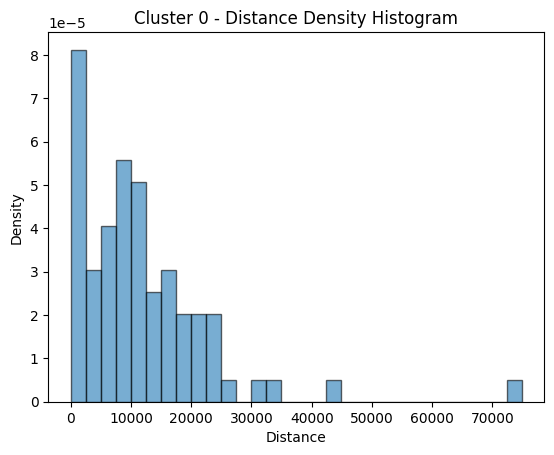

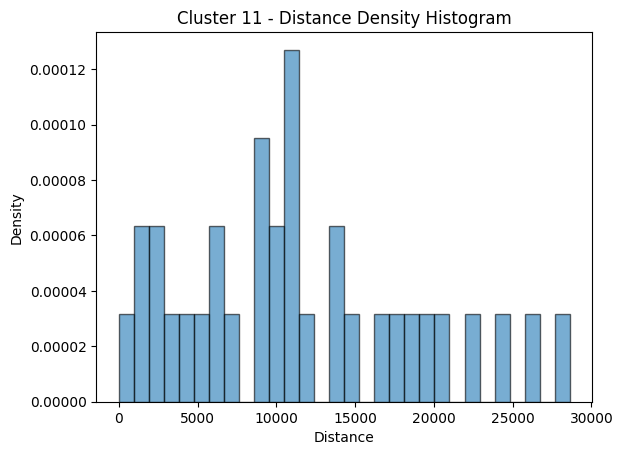

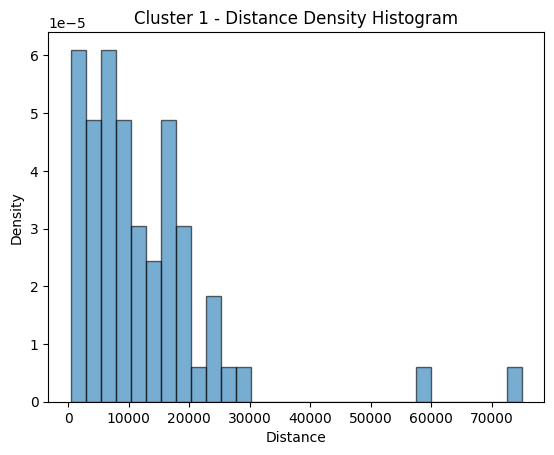

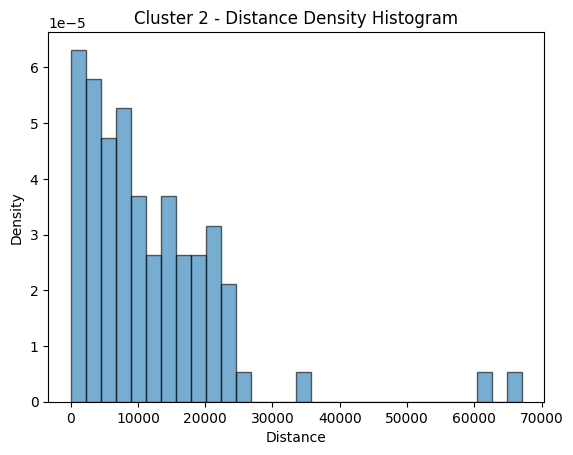

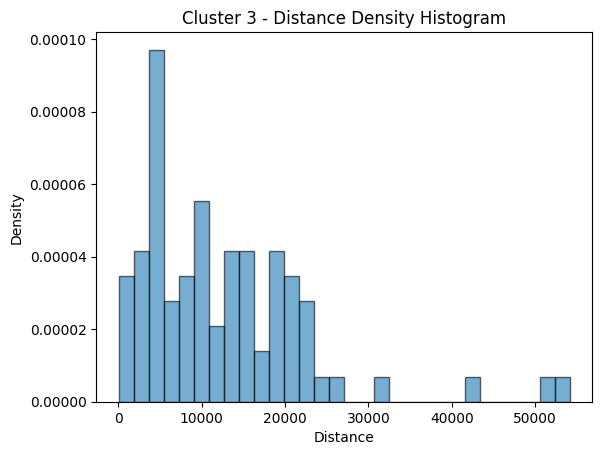

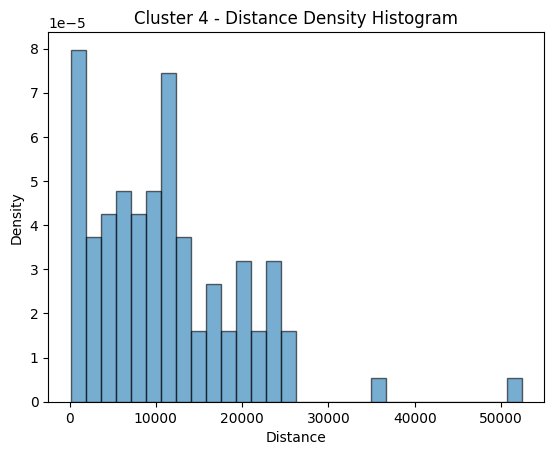

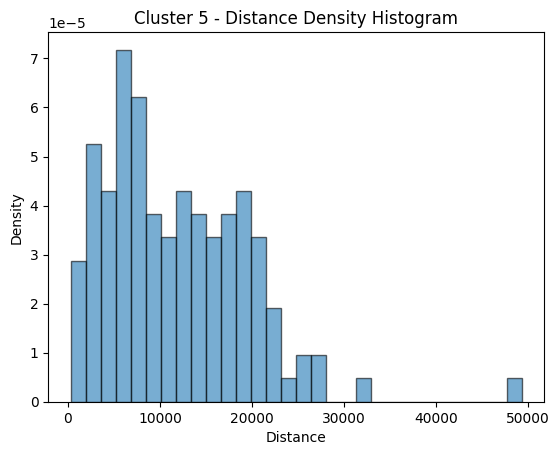

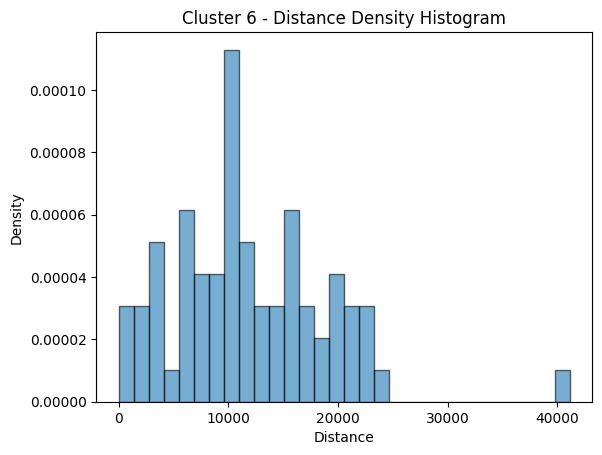

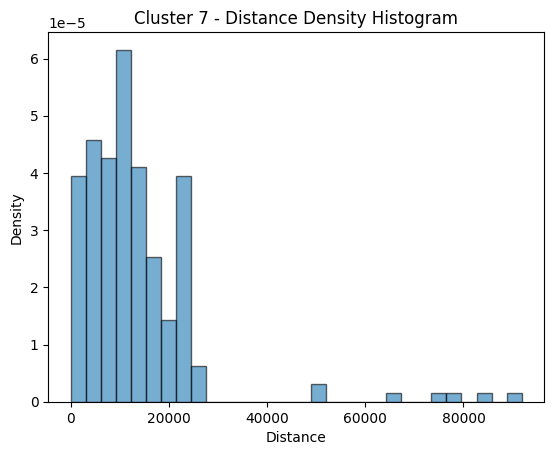

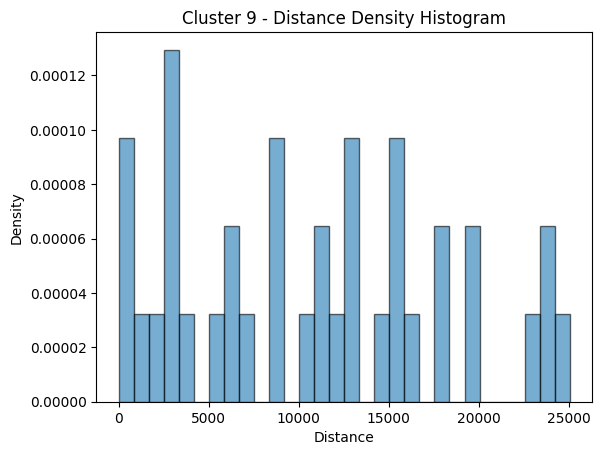

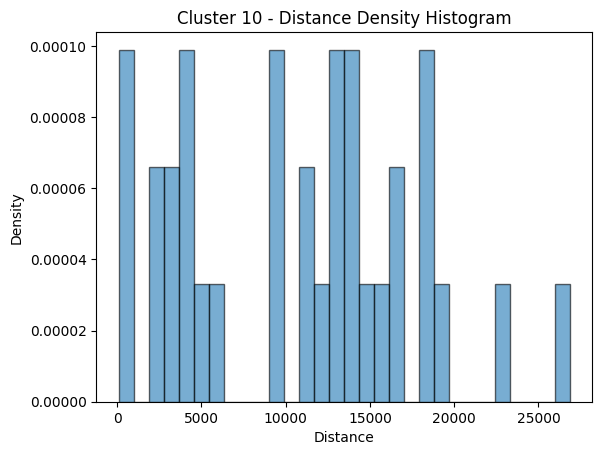

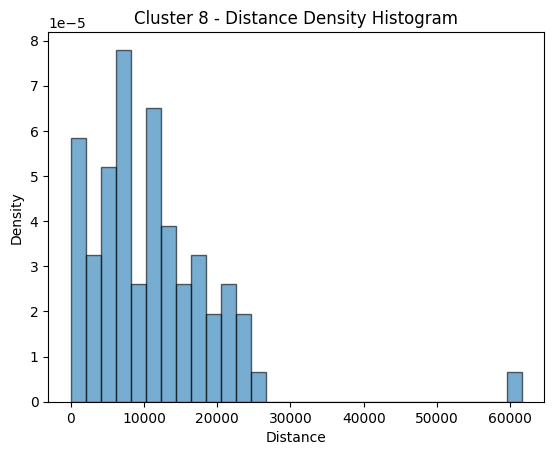

In [16]:
from utils import weighted_distance_calculation
#importlib.reload(weighted_distance_calculation)

weighted_distance_calculation.plot_density_histograms('../data/outlier_cleaned_by_DBSCAN.csv')

In [17]:
from utils import outlier_detection_by_dist
#importlib.reload(outlier_detection_by_dist)


threshold = {'0':30000, '1':30000 ,'2':30000, '3':30000, '4':30000, '5':15000 ,'6':21000
             ,'7':25000 , '8':12000 ,'9':25000, '10':20000, '11':20000, '12':22000 }

outlier_detection_by_dist.filter_and_save_by_cluster('../data/weighted_distances.csv', threshold, plot=False)

Filtered dataframe has been saved to '../data/final_cleaned.csv'
Outliers have been saved to '../data/outliers.csv'


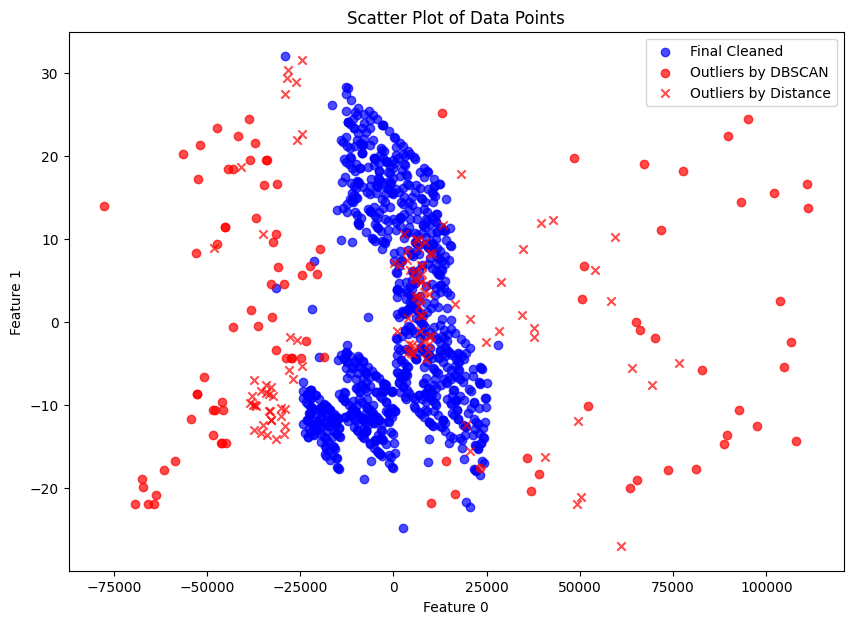

In [18]:
from utils import final_plot
#importlib.reload(final_plot)

final_plot.plot_data_points()

In [8]:


# Step 2: Load mappings and column mappings
with open('mappings.pkl', 'rb') as f:
    mappings, column_mapping = pickle.load(f)

In [9]:
if isinstance(mappings, dict):
    print("Mappings loaded correctly!")
else:
    print("Mappings is not a dictionary. Check the file or the saving/loading process.")

Mappings loaded correctly!


In [11]:
# Step 4: Load the encoded DataFrame
result = pd.read_csv('/Users/navid/Documents/1_Projects/0_Age-It/Our Tasks/Privacy/Privgen/data/final_cleaned.csv')

# Step 5: Verify the DataFrame columns
print("Result columns:", result.columns)

Result columns: Index(['col_0', 'col_1', 'col_2', 'col_3', 'col_4', 'col_5', 'col_6', 'col_7',
       'col_8', 'col_9', 'Age', 'Salary', 'cluster', 'distance'],
      dtype='object')


In [13]:
import pandas as pd
from utils import data_encoder
#importlib.reload(data_encoder)
result = pd.read_csv('/Users/navid/Documents/1_Projects/0_Age-It/Our Tasks/Privacy/Privgen/data/final_cleaned.csv')
decoded = data_encoder.decode_categorical(encoded_data, mappings, column_mapping)

TypeError: tuple indices must be integers or slices, not str

In [9]:
mappings

{'Gender': {'forward': {'Non-binary': '355ef4f68fed35b082cf0bccc0ab054d',
   'Male': '63889cfb9d3cbe05d1bd2be5cc9953fd',
   'Female': 'b719ce180ec7bd9641fece2f920f4817'},
  'reverse': {'355ef4f68fed35b082cf0bccc0ab054d': 'Non-binary',
   '63889cfb9d3cbe05d1bd2be5cc9953fd': 'Male',
   'b719ce180ec7bd9641fece2f920f4817': 'Female'}},
 'City': {'forward': {'Venice': '607d28488d1859e84884914a1b3598bd',
   'Parma': '85bf516cb6ae2cc86249d1e7b9fa890c',
   'Trieste': '1d8b2ddc05f3f931791003d2ccd75e43',
   'Milan': '437d461430ecc08e2d51abbcf5ce9b3c',
   'Padua': '48a09f4956b196a2489d69e3c117000d',
   'Verona': 'd32a635cff5dcc73a609d313801541d4',
   'Genoa': '5e59a42459a2d6cd3d93d5aab0764ca6',
   'Bologna': '7014d0181914fb4722b90a49d53f5471',
   'Brescia': '0c3c889cb60322b10d890d76a05f816e',
   'Turin': '42dc29389d6318f0fe5b21396ce73b22'},
  'reverse': {'607d28488d1859e84884914a1b3598bd': 'Venice',
   '85bf516cb6ae2cc86249d1e7b9fa890c': 'Parma',
   '1d8b2ddc05f3f931791003d2ccd75e43': 'Trieste',
 